# Notebook purpose

This notebook preserves the exploratory workflow from `analise_parti.ipynb`.

Purpose: Explore party-year semantic trajectories derived from pooled embeddings.

Related production code/script: `src/clustering/party.py`, `scripts/run_clustering.py --stage party`.


In [ ]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import os
import umap.umap_ as umap
import matplotlib.pyplot as plt
import seaborn as sns

import re

In [3]:
print("Iniciando a análise do 'DNA dos Partidos'...")

# --- Passo 1: Carregar e Preparar os Dados ---
print("Carregando dados pré-processados...")
try:
    df = pd.read_csv('data/discursos_camara_2003_2025_limpos.csv')
    embeddings = np.load('data/discursos_camara_2003_2025_limpos_Linq_embeddings_norm.npy')
    assert len(df) == len(embeddings), "O número de linhas no CSV e nos embeddings não bate!"
except FileNotFoundError:
    print("Erro: Arquivos 'discursos_limpos.csv' ou 'embeddings_discursos.npy' não encontrados.")
    exit()

# --- Passo 2: Agregar Embeddings por PARTIDO e Ano ---
print("Agregando embeddings por partido e por ano...")
embedding_list = [emb for emb in embeddings]
df['embedding'] = embedding_list


Iniciando a análise do 'DNA dos Partidos'...
Carregando dados pré-processados...


Agregando embeddings por partido e por ano...


Embeddings agregados para 226 combinações de partido/ano.
Reduzindo a dimensionalidade de todos os pontos (partido/ano) com UMAP...


/home/flaviossf/defaultenv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/flaviossf/defaultenv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Preparando dados para a visualização...
Gerando o gráfico de trajetórias...


Desenhando trajetórias:   0%|          | 0/11 [00:00<?, ?it/s]


✔️ Gráfico de trajetórias salvo como 'mapa_trajetoria_partidos_Linq.png'


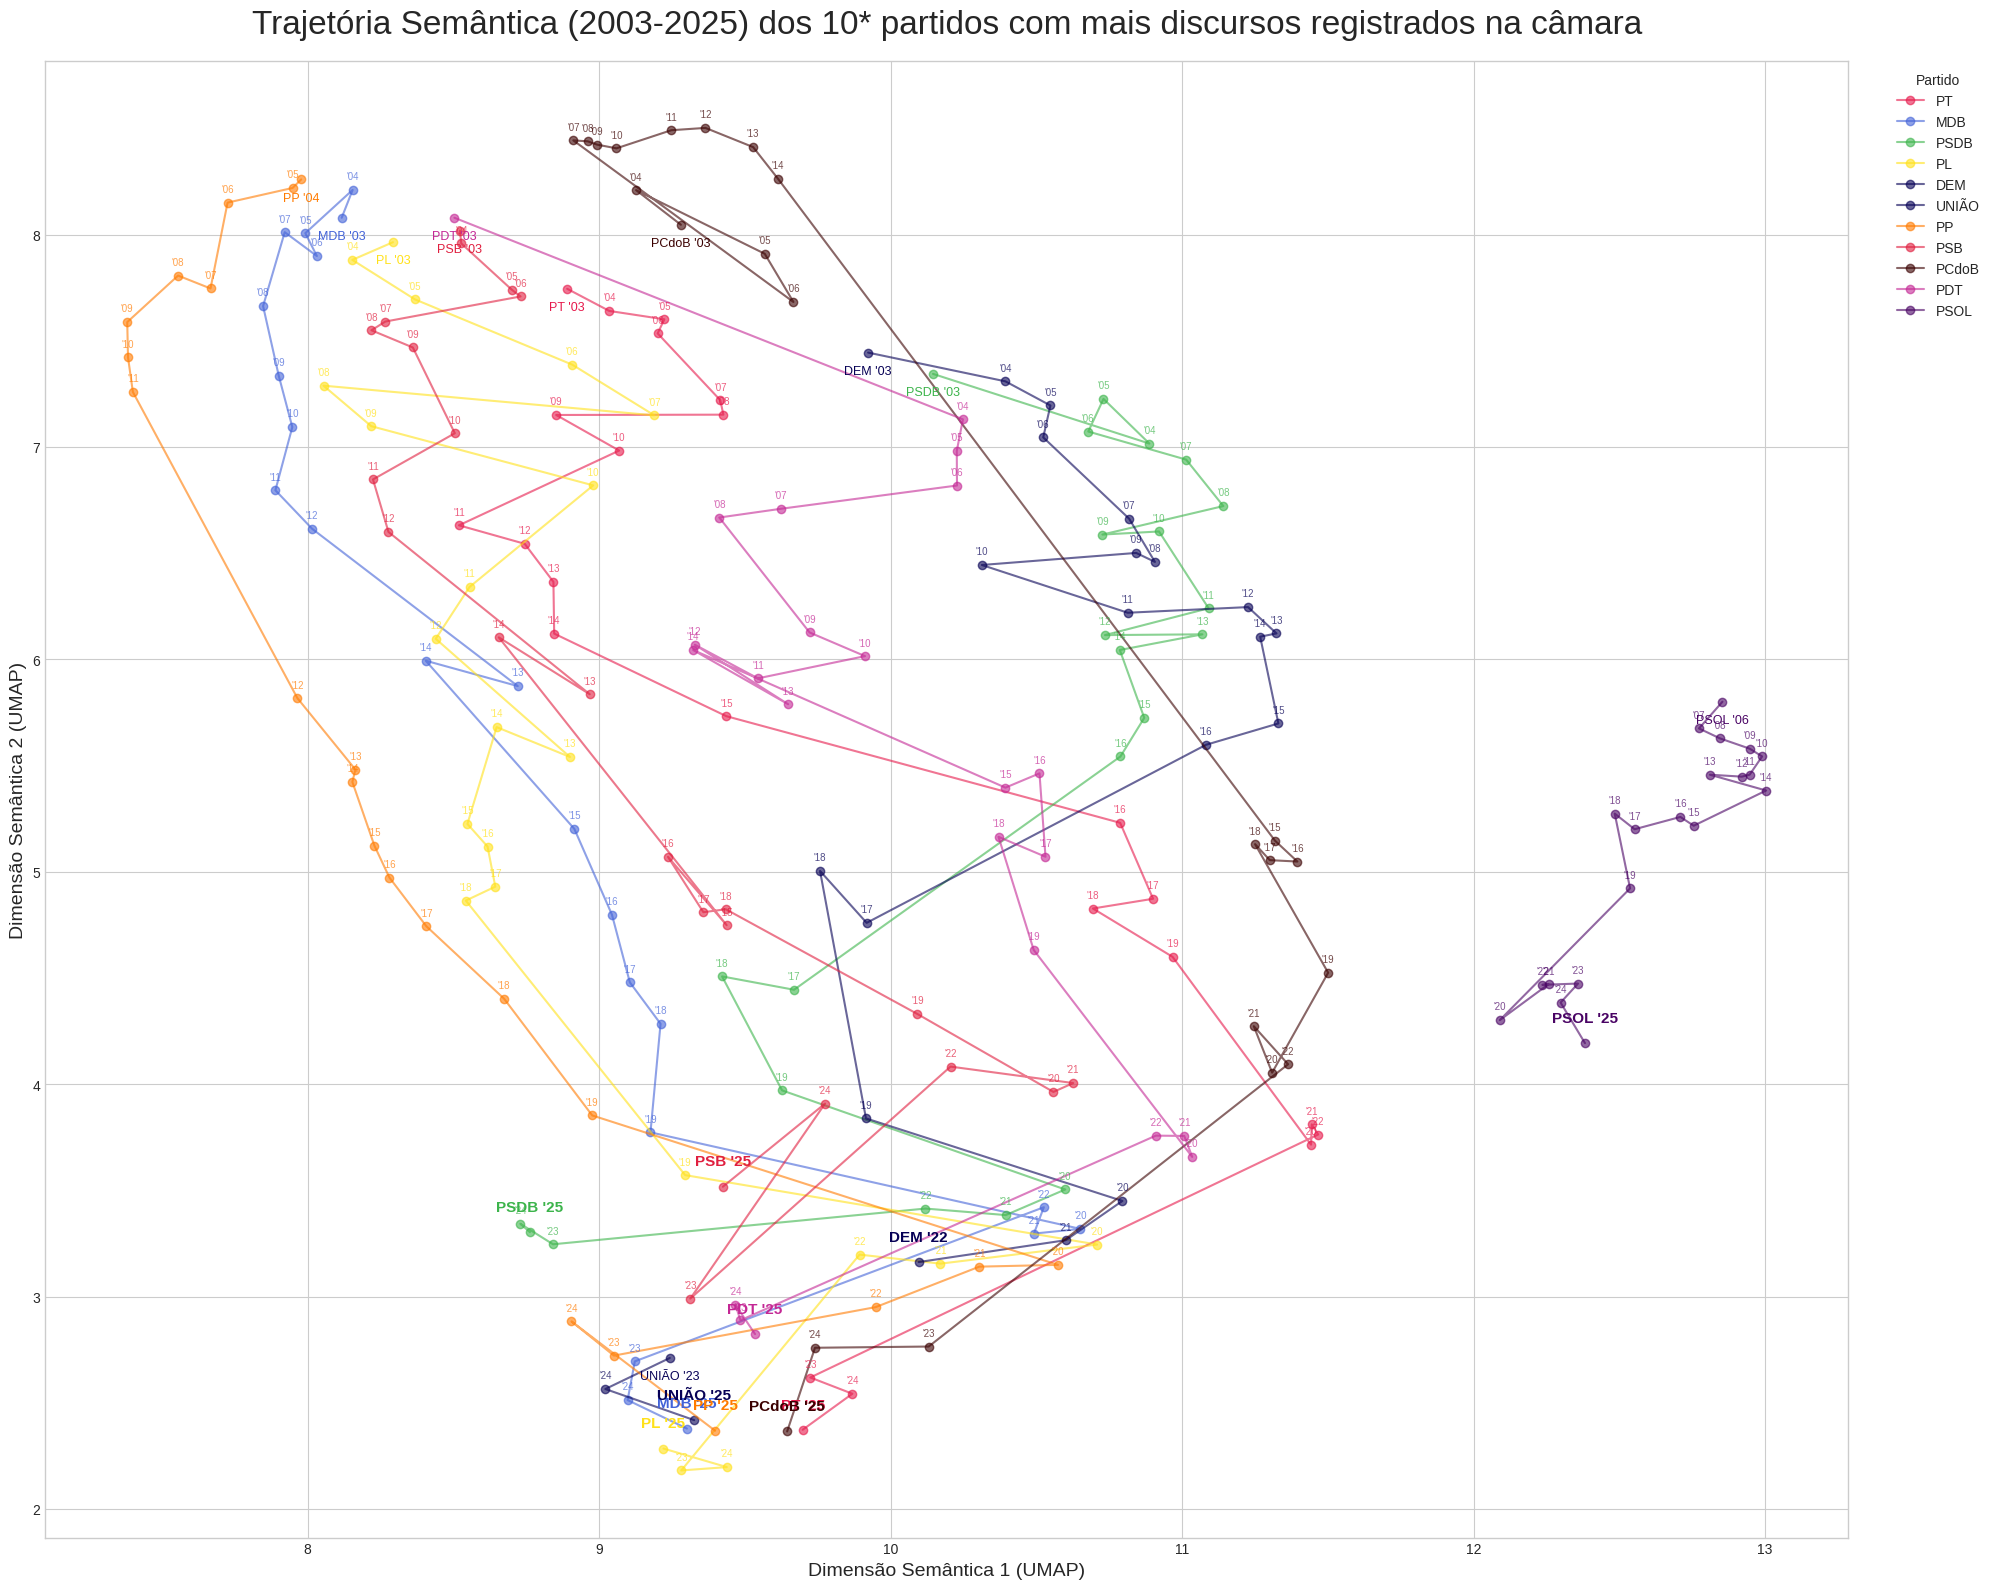

In [4]:
# --- Dicionário de Cores (incluindo os partidos antigos) ---
party_colors = {
    # Paleta de alto contraste para máxima diferenciação visual.
    "PT": "#E6194B",    # Vermelho
    "MDB": "#4363d8",    # Azul
    "PSDB": "#3cb44b",  # Verde
    "PL": "#ffe119",    # Amarelo
    "DEM": "#060055",    # Magenta
    "UNIÃO": "#060055",  # Laranja
    "PP": "#ff7b00",    # Roxo
    "PSB": "#e01f3f",    # Laranja
    "PCdoB": "#3A0000",  # Marrom (Vinho)
    "PDT": "#c42895",    # Ciano
    "PSOL": "#490364",   # Marrom (Sépia)
}
df_filtrado = df[df['partido'].isin(party_colors.keys())]

# A MUDANÇA PRINCIPAL ESTÁ AQUI: agrupamos por 'ano' e 'partido'
party_year_embeddings_df = df_filtrado.groupby(['ano', 'partido'])['embedding'].apply(lambda x: np.mean(x.tolist(), axis=0))
party_year_embeddings_df = pd.DataFrame(party_year_embeddings_df.tolist(), index=party_year_embeddings_df.index)


print(f"Embeddings agregados para {len(party_year_embeddings_df)} combinações de partido/ano.")

# --- Passo 3: Reduzir a Dimensionalidade com UMAP ---
print("Reduzindo a dimensionalidade de todos os pontos (partido/ano) com UMAP...")
neighbors_umap = 40
reducer = umap.UMAP(n_neighbors=neighbors_umap, min_dist=0.1, n_components=2, random_state=33)
# 15, 0.1, 2, 33
embedding_2d = reducer.fit_transform(party_year_embeddings_df)

# --- Passo 4: Preparar DataFrame Final para Plotagem ---
print("Preparando dados para a visualização...")
df_plot = pd.DataFrame(embedding_2d, columns=['x', 'y'])
df_plot[['ano', 'partido']] = party_year_embeddings_df.index.to_frame(index=False)

# --- Passo 5: Visualização das Trajetórias ---

print("Gerando o gráfico de trajetórias...")
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(20, 16))



# Loop para desenhar a trajetória de cada partido
for partido in tqdm(party_colors.keys(), desc="Desenhando trajetórias"):
    df_partido = df_plot[df_plot['partido'] == partido].sort_values('ano')
    
    if not df_partido.empty:
        # Pega a cor do nosso dicionário, ou usa cinza se não encontrar
        color = party_colors.get(partido, '#808080')
        
        # Desenha a linha da trajetória
        ax.plot(df_partido['x'], df_partido['y'], marker='o', linestyle='-', color=color, label=partido, alpha=0.6)
        
        # Adiciona texto para cada ponto de ano
        for i, row in df_partido.iterrows():
            year_label = str(row['ano'])[-2:] # Pegar os últimos dois dígitos do ano
            if i == df_partido.index[0]: # Primeiro ponto
                ax.text(row['x'], row['y'] - 0.1, f"{partido} '{year_label}", fontsize=9, color=color, ha='center')
            elif i == df_partido.index[-1]: # Último ponto
                ax.text(row['x'], row['y'] + 0.1, f"{partido} '{year_label}", fontsize=11, color=color, ha='center', weight='bold')
            else: # Pontos intermediários
                ax.text(row['x'], row['y'] + 0.05, f"'{year_label}", fontsize=7, color=color, ha='center', alpha=0.7)

# Configurações finais do gráfico
ax.set_title('Trajetória Semântica (2003-2025) dos 10* partidos com mais discursos registrados na câmara', fontsize=24, pad=20)
ax.set_xlabel('Dimensão Semântica 1 (UMAP)', fontsize=14)
ax.set_ylabel('Dimensão Semântica 2 (UMAP)', fontsize=14)
ax.legend(title='Partido', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(f'mapa_trajetoria_partidos_Linq_{neighbors_umap}neighbors.png', dpi=300)
print("\n✔️ Gráfico de trajetórias salvo como 'mapa_trajetoria_partidos_Linq.png'")
plt.show()